In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [4]:
df = pd.read_csv("car data.csv")

print(df.head())
print(df.info())
print(df.describe())

  Car_Name  Year  Selling_Price  Present_Price  Driven_kms Fuel_Type  \
0     ritz  2014           3.35           5.59       27000    Petrol   
1      sx4  2013           4.75           9.54       43000    Diesel   
2     ciaz  2017           7.25           9.85        6900    Petrol   
3  wagon r  2011           2.85           4.15        5200    Petrol   
4    swift  2014           4.60           6.87       42450    Diesel   

  Selling_type Transmission  Owner  
0       Dealer       Manual      0  
1       Dealer       Manual      0  
2       Dealer       Manual      0  
3       Dealer       Manual      0  
4       Dealer       Manual      0  
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 301 entries, 0 to 300
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Car_Name       301 non-null    object 
 1   Year           301 non-null    int64  
 2   Selling_Price  301 non-null    float64
 3   Present_Price  3

In [5]:
print(df.isnull().sum())

Car_Name         0
Year             0
Selling_Price    0
Present_Price    0
Driven_kms       0
Fuel_Type        0
Selling_type     0
Transmission     0
Owner            0
dtype: int64


In [7]:
df.dropna(inplace=True)

In [6]:
current_year = 2025
df["Car_Age"] = current_year - df["Year"]

df.drop(["Year"], axis=1, inplace=True)

In [8]:
le = LabelEncoder()

df["Fuel_Type"] = le.fit_transform(df["Fuel_Type"])
df["Selling_type"] = le.fit_transform(df["Selling_type"])
df["Transmission"] = le.fit_transform(df["Transmission"])
df["Car_Name"] = le.fit_transform(df["Car_Name"])

In [9]:
X = df.drop("Selling_Price", axis=1)
y = df["Selling_Price"]

In [10]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [11]:
model = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

model.fit(X_train, y_train)

RandomForestRegressor(random_state=42)

In [12]:
y_pred = model.predict(X_test)

In [13]:
print("MAE:", mean_absolute_error(y_test, y_pred))
print("MSE:", mean_squared_error(y_test, y_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred)))
print("R2 Score:", r2_score(y_test, y_pred))

MAE: 0.6021950819672133
MSE: 0.7969036719672131
RMSE: 0.8926946129372648
R2 Score: 0.9654055371911539


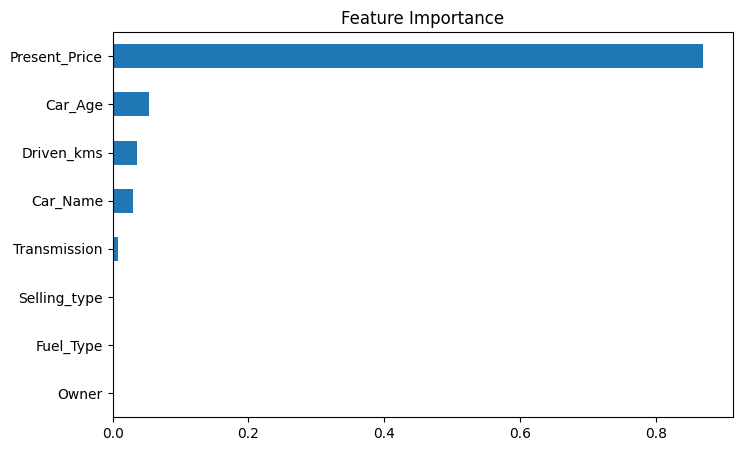

In [14]:
importance = pd.Series(model.feature_importances_, index=X.columns)

importance.sort_values().plot(
    kind="barh",
    figsize=(8,5)
)

plt.title("Feature Importance")
plt.show()

In [16]:
sample = [[
    50,      # Encoded Car_Name
    5.5,     # Present_Price
    35000,   # Driven_kms
    2,       # Fuel_Type
    0,       # Selling_type
    1,       # Transmission
    0,       # Owner
    5        # Car_Age
]]

predicted_price = model.predict(sample)

print("Predicted Selling Price:", predicted_price[0], "Lakhs")

Predicted Selling Price: 3.472000000000001 Lakhs


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(
